# MIS 589 — Group Assignment 1
## Airbnb Dallas: Superhost Status, Bookings and Revenue

**Dataset:** `airbnb_dallas.csv` — 48,711 rows x 111 columns.

**Important — this is panel data, not a list of listings.** Each row is **one property in one
Superhost evaluation period**, identified by `Airbnb Property ID` + `superhost_period_all`.
A single property appears in many rows. So any "average for Superhosts" below is an average
over *property-periods* unless we say otherwise.

Most columns have a `prev_` twin holding the same measure from the previous period
(`revenue` / `prev_revenue`, `booked_days` / `prev_booked_days`, ...). That is what makes the
before/after comparison in Question 7 possible within a single row.

Questions 1-8 are answered below. Each question has its own heading, one code cell, and a
written interpretation.

## Setup — load the data once

In [1]:
# Libraries: pandas for the data, matplotlib + seaborn for charts,
# scipy for the significance tests used in Q5 and Q7.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings so wide tables and charts print readably.
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Load once. Every question below reuses this dataframe.
df = pd.read_csv('airbnb_dallas.csv', low_memory=False)

# Basic shape of the dataset and how many real properties it covers.
print('Rows, columns:', df.shape)
print('Distinct properties :', df['Airbnb Property ID'].nunique())
print('Evaluation periods  :', int(df['superhost_period_all'].min()), 'to',
      int(df['superhost_period_all'].max()))
print()

# Superhost flag: confirm the two status columns agree before we rely on one of them.
# .mean() on a True/False series gives the share that are True, so this is the
# fraction of rows where the flags match. 1.0 = they are fully redundant.
agree = (df['Superhost'] == df['host_is_superhost_in_period']).mean()
print("'Superhost' agrees with 'host_is_superhost_in_period' on {:.1%} of rows".format(agree))
print(df['Superhost'].value_counts().rename({0.0: 'Non-Superhost', 1.0: 'Superhost'}))
print()

# Readable group label used by every chart from here on.
df['Superhost status'] = np.where(df['Superhost'] == 1, 'Superhost', 'Non-Superhost')

# --- How missing values behave in this dataset (matters for Q2 and Q6) ---
# booked_days and revenue are null on the same rows. Those rows still have available_days,
# so they are property-periods that were listed but never booked - a real zero, not a
# recording failure. We report both readings rather than dropping them silently.
# A boolean mask: True on every row where booked_days was not recorded.
nb_null = df['booked_days'].isna()
print('Rows with null booked_days / revenue :', int(nb_null.sum()),
      '({:.1%} of all rows)'.format(nb_null.mean()))
print('  ... of those, rows that still have available_days recorded:',
      int(df.loc[nb_null, 'available_days'].notna().sum()))
print('  min recorded booked_days:', df['booked_days'].min(),
      '| min recorded revenue:', df['revenue'].min())
print('  -> no row records a literal 0, so null = "listed but no bookings in the period".')

# Zero-filled versions, used only where we say so explicitly.
# Zero-filled copies of the two columns, used only where we say so explicitly.
df['booked_days_z'] = df['booked_days'].fillna(0)
df['revenue_z'] = df['revenue'].fillna(0)

Rows, columns: (48711, 111)
Distinct properties : 9599
Evaluation periods  : 5 to 20

'Superhost' agrees with 'host_is_superhost_in_period' on 100.0% of rows
Superhost
Non-Superhost    32791
Superhost        15920
Name: count, dtype: int64

Rows with null booked_days / revenue : 16861 (34.6% of all rows)
  ... of those, rows that still have available_days recorded: 9550
  min recorded booked_days: 1.0 | min recorded revenue: 10.0
  -> no row records a literal 0, so null = "listed but no bookings in the period".


---
# Question 1 — Range and IQR of Nightly Rate

> *Calculate the range and interquartile range (IQR) of Nightly Rate for the dataset. What do
> these measures tell you about the spread and variability of nightly rates across listings?*

**Approach.** Report count, min, max, range, Q1, Q3, IQR and median. The pair matters more
than either number alone: the range is set by the two most extreme listings in the file, while
the IQR describes the middle half of the market and ignores the tails. We also list the five
highest and five lowest rates so we can judge whether the extremes are real listings or data
errors. **No outliers are removed.**

Nightly Rate (USD) — spread statistics
Count (non-null)     48711.00
Missing                  0.00
Minimum                  1.00
Maximum               1900.00
Range (max-min)       1899.00
Q1 (25th pct)           69.00
Median (50th pct)      107.50
Q3 (75th pct)          185.12
IQR (Q3-Q1)            116.12
Mean                   157.17
Std deviation          169.89

Rows used: 48711 of 48711 (null Nightly Rate: 0)

5 highest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0

5 lowest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
       

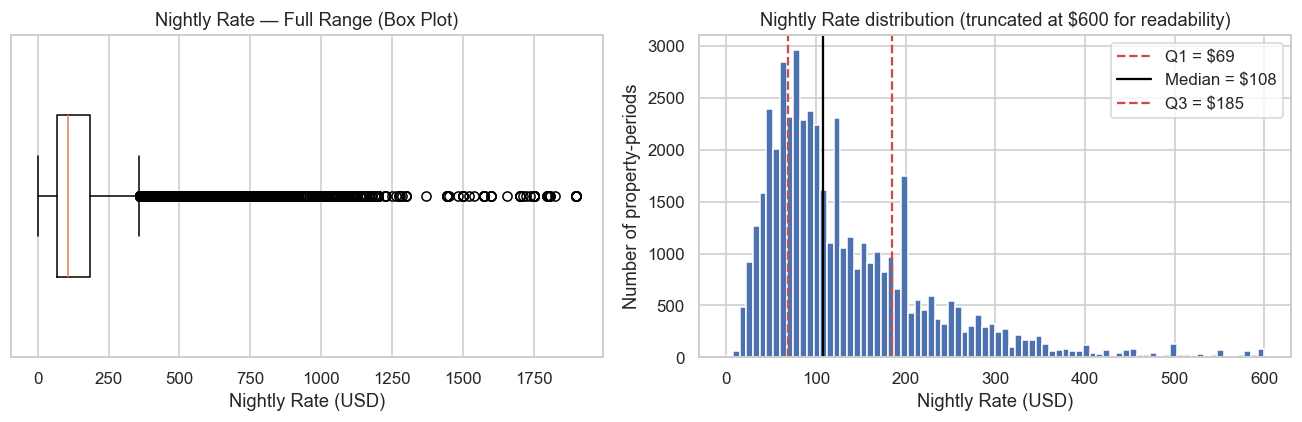

In [2]:
# Q1: how spread out are nightly rates?
nr = df['Nightly Rate']

# Q1/Q3 are the 25th and 75th percentiles - the two values that bound the middle
# half of the market. The IQR is the width of that band.
q1, q3 = nr.quantile(0.25), nr.quantile(0.75)
# Collect every spread statistic into one labelled table.
summary = pd.Series({
    'Count (non-null)': nr.notna().sum(),
    'Missing':          nr.isna().sum(),
    'Minimum':          nr.min(),
    'Maximum':          nr.max(),
    'Range (max-min)':  nr.max() - nr.min(),
    'Q1 (25th pct)':    q1,
    'Median (50th pct)': nr.median(),
    'Q3 (75th pct)':    q3,
    'IQR (Q3-Q1)':      q3 - q1,
    'Mean':             nr.mean(),
    'Std deviation':    nr.std(),
})
print('Nightly Rate (USD) — spread statistics')
print('=' * 46)
print(summary.round(2).to_string())
print()
print('Rows used: {} of {} (null Nightly Rate: {})'.format(nr.notna().sum(), len(df), nr.isna().sum()))
print()

# List the most extreme listings so we can judge whether they are real or data errors.
cols = ['Airbnb Property ID', 'Neighborhood', 'Listing Type', 'Bedrooms', 'Nightly Rate']
print('5 highest nightly rates')
# nlargest/nsmallest return whole ROWS ranked by one column. Because this is panel
# data these 5 rows can be the same property in 5 different periods, not 5 listings.
print(df.nlargest(5, 'Nightly Rate')[cols].to_string(index=False))
print()
print('5 lowest nightly rates')
print(df.nsmallest(5, 'Nightly Rate')[cols].to_string(index=False))
print()

# How much of the market sits inside the IQR box vs out in the tail?
# between() gives True/False per row; .mean() turns that into a percentage.
inside = nr.between(q1, q3).mean()
print('Share of listings priced between Q1 (${:.0f}) and Q3 (${:.0f}): {:.1%}'.format(q1, q3, inside))
print('Share priced above $500: {:.2%}   above $1,000: {:.2%}'.format((nr > 500).mean(), (nr > 1000).mean()))
print('99th percentile: ${:.2f}'.format(nr.quantile(0.99)))

# Box plot of the full range to show how far the outliers reach, next to a histogram
# zoomed into the main market to show where listings actually cluster.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(nr.dropna(), vert=False, widths=0.5)
axes[0].set_title('Nightly Rate — Full Range (Box Plot)')
axes[0].set_xlabel('Nightly Rate (USD)')
axes[0].set_yticks([])
# range= cuts the x-axis at $600 so the bars are visible; it hides the long tail,
# which is why the box plot beside it shows the full range instead.
axes[1].hist(nr.dropna(), bins=80, range=(0, 600), color='#4C72B0', edgecolor='white')
axes[1].axvline(q1, color='#C44E52', ls='--', label='Q1 = ${:.0f}'.format(q1))
axes[1].axvline(nr.median(), color='black', ls='-', label='Median = ${:.0f}'.format(nr.median()))
axes[1].axvline(q3, color='#C44E52', ls='--', label='Q3 = ${:.0f}'.format(q3))
axes[1].set_title('Nightly Rate distribution (truncated at $600 for readability)')
axes[1].set_xlabel('Nightly Rate (USD)')
axes[1].set_ylabel('Number of property-periods')
axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 1

Range = $1,899 (min $1, max $1,900). IQR = $116.12 (Q1 $69.00, Q3 $185.12), median $107.50.

The two measures tell very different stories, and the gap between them *is* the finding: the
range is more than 16 times the IQR. The middle half of the Dallas market is packed into a
narrow $116 band just under $200 a night, while the full range is stretched across nearly $1,900
by a thin tail of luxury listings — only 3.7% of property-periods are priced above $500 and
1.1% above $1,000.

That makes the range a poor description of variability here. It is set by exactly two rows and
is destroyed by a single outlier, whereas the IQR describes where listings actually sit. The
mean ($157.17) sitting well above the median ($107.50) confirms the same right skew.

On the extremes. We did not remove them, but they should be read with suspicion. The five
highest rows are all the *same property* (ID 18054750, a 2-bedroom Central Dallas home) observed
in five different periods at $1,900 — a reminder that this is panel data, so the "top 5 rows"
are not 5 different listings. The $1 minimum is likewise one property (ID 20678468) listed with
0 bedrooms, which looks like a placeholder or data-entry error rather than a real market price.
A single bad row moves the range by hundreds of dollars and the IQR not at all.

---
# Question 2 — Descriptive statistics for `booked_days` and `revenue`

> *Provide a summary of key descriptive statistics (mean, median, standard deviation, minimum,
> and maximum) for booked_days and revenue. How do these statistics help you understand the
> overall performance of the properties?*

**Approach.** One table with count, mean, median, std, min and max for both variables. The
mean-to-median ratio is the number to read: if the mean sits well above the median, a minority
of high earners is pulling the average up and the median is the better description of a typical
property.

Because null `booked_days` / `revenue` means "listed but never booked" (see Setup), we print the
table twice — once over booked property-periods only, and once with those rows counted as zero.
The second version is the honest picture of *all* listed inventory.

Null values — booked_days: 16861   revenue: 16861

A. Booked property-periods only (nulls excluded) — n = 31850
------------------------------------------------------------
         booked_days    revenue
Count       31850.00   31850.00
Mean           25.47    3134.13
Median         22.00    2025.00
Std dev        18.77    4249.34
Minimum         1.00      10.00
Maximum       173.00  134209.00

  booked_days  mean/median ratio = 1.16
  revenue      mean/median ratio = 1.55

B. All property-periods, unbooked counted as 0 — n = 48711
----------------------------------------------------------
         booked_days_all  revenue_all
Count           48711.00     48711.00
Mean               16.65      2049.27
Median              9.00       787.00
Std dev            19.42      3745.62
Minimum             0.00         0.00
Maximum           173.00    134209.00

  booked_days_all mean/median ratio = 1.85
  revenue_all  mean/median ratio = 2.60

Percentiles (booked periods only)
          booked_d

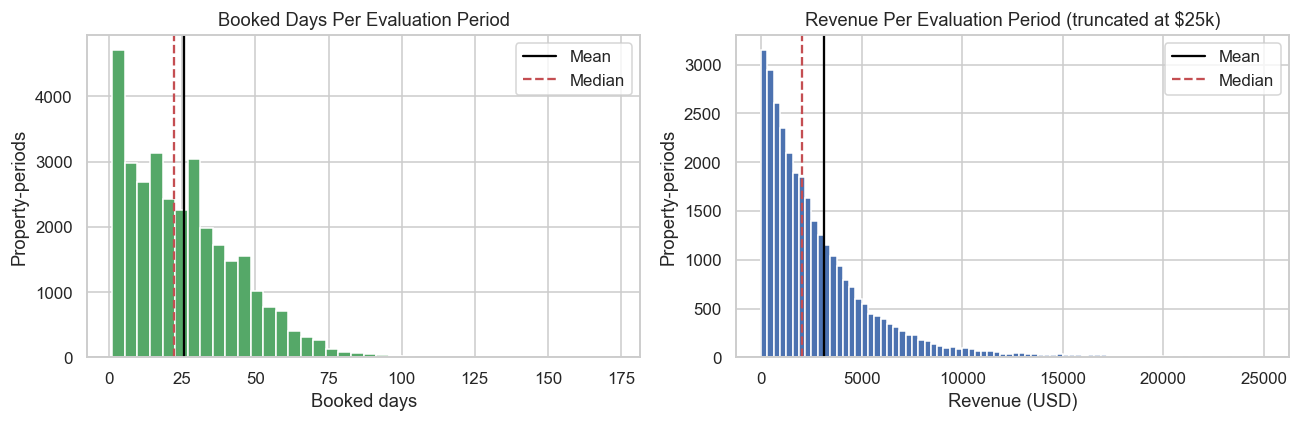

In [3]:
# Builds the same summary table for any set of columns, so we can run it twice:
# once on booked rows only, once with unbooked periods counted as zero.
def describe_pair(frame, cols, label):
    # Dict-of-dicts -> DataFrame puts statistics in rows and variables in columns.
    out = pd.DataFrame({
        c: {
            'Count':    frame[c].notna().sum(),
            'Mean':     frame[c].mean(),
            'Median':   frame[c].median(),
            'Std dev':  frame[c].std(),
            'Minimum':  frame[c].min(),
            'Maximum':  frame[c].max(),
        } for c in cols
    })
    print(label)
    print('-' * len(label))
    print(out.round(2).to_string())
    print()
    for col in cols:
        m, md_ = frame[col].mean(), frame[col].median()
        print('  {:<12} mean/median ratio = {:.2f}'.format(col, m / md_))
    print()
    return out

# How many property-periods have no booking data at all.
print('Null values — booked_days: {}   revenue: {}'.format(
    df['booked_days'].isna().sum(), df['revenue'].isna().sum()))
print()

# Table A = booked periods only. Table B = the same stats with unbooked periods
# counted as zero, which is the honest view of all listed inventory.
a = describe_pair(df, ['booked_days', 'revenue'],
                  'A. Booked property-periods only (nulls excluded) — n = {}'.format(
                      df['booked_days'].notna().sum()))
b = describe_pair(df.rename(columns={'booked_days_z': 'booked_days_all', 'revenue_z': 'revenue_all'}),
                  ['booked_days_all', 'revenue_all'],
                  'B. All property-periods, unbooked counted as 0 — n = {}'.format(len(df)))

# Percentiles give a fuller sense of the spread than min/max alone.
pct = df[['booked_days', 'revenue']].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(2)
pct.index = ['10th pct', '25th pct', '50th pct', '75th pct', '90th pct', '99th pct']
print('Percentiles (booked periods only)')
print(pct.to_string())
print()
# Revenue earned by the top 10% of rows, divided by revenue earned by everyone.
# A high number means earnings are concentrated in a few listings.
top10_share = df.nlargest(int(0.10 * df['revenue'].notna().sum()), 'revenue')['revenue'].sum() / df['revenue'].sum()
print('Share of all revenue earned by the top 10% of property-periods: {:.1%}'.format(top10_share))

# Histograms of booked_days and revenue to show the shape behind those averages,
# with mean and median marked so the skew is visible.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['booked_days'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[0].axvline(df['booked_days'].mean(), color='black', ls='-', label='Mean')
axes[0].axvline(df['booked_days'].median(), color='#C44E52', ls='--', label='Median')
axes[0].set_title('Booked Days Per Evaluation Period')
axes[0].set_xlabel('Booked days'); axes[0].set_ylabel('Property-periods'); axes[0].legend()
axes[1].hist(df['revenue'].dropna(), bins=80, range=(0, 25000), color='#4C72B0', edgecolor='white')
axes[1].axvline(df['revenue'].mean(), color='black', ls='-', label='Mean')
axes[1].axvline(df['revenue'].median(), color='#C44E52', ls='--', label='Median')
axes[1].set_title('Revenue Per Evaluation Period (truncated at $25k)')
axes[1].set_xlabel('Revenue (USD)'); axes[1].set_ylabel('Property-periods'); axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 2

**Booked property-periods only (n = 31,850):**

| | booked_days | revenue |
|---|---|---|
| Mean | 25.47 | $3,134.13 |
| Median | 22.00 | $2,025.00 |
| Std dev | 18.77 | $4,249.34 |
| Min | 1.00 | $10.00 |
| Max | 173.00 | $134,209.00 |

What these say about performance. The typical booked property earns about $2,025 per
evaluation period on 22 booked days. The mean/median ratios separate the two variables
cleanly: `booked_days` is only mildly skewed (ratio 1.16), because it is physically capped
by the length of the period, and its max of 173 days is a real ceiling. Revenue has no such cap,
and its ratio of 1.55 — plus a standard deviation ($4,249) larger than its own mean —
shows a small group of very high earners pulling the average up. The top 10% of
property-periods take 38.6% of all revenue. Quoting the $3,134 mean as "typical" would
overstate what a normal host makes by more than 50%.

The bigger performance story is the rows that are not in that table. 16,861
property-periods (34.6%) have no booked days at all. Counting those as zero, which is the
honest view of all listed inventory, the picture changes sharply: median revenue falls from
$2,025 to $787 and median booked days from 22 to 9. So roughly a third of Dallas
inventory is listed but idle, and any performance claim needs to state which of the two
populations it describes.

---
# Question 3 — Booking patterns: Superhosts vs non-Superhosts

> *What can you infer about booking patterns for Superhosts compared to non-Superhosts?
> Determine the best way to visualize the booked_days data and explain your findings.*

Chart choice and why: 
Side-by-side box plots, with overlapping density curves as a second view. A bar chart of two means would hide the spread, and spread is the whole point of a booking-pattern comparison — box plots show median, IQR and outliers for both groups at once, and the density curves show whether the two distributions have different *shapes* or just different centres.

Watch for: The groups are very different sizes, so we print group counts alongside and
compare medians as well as means.

Rows used: 31850 of 48711 (16861 dropped for null booked_days)

booked_days by Superhost status
                  Count   Mean  Median  Std dev    Q1    Q3    Max   IQR
Superhost status                                                        
Non-Superhost     18987  23.67    20.0    18.67   8.0  35.0  173.0  27.0
Superhost         12863  28.12    26.0    18.62  13.0  40.0  133.0  27.0

Difference in means  (Superhost - Non): +4.46 days
Difference in medians (Superhost - Non): +6.00 days
Superhost median is 1.3x the non-Superhost median

Share of property-periods with NO bookings at all:
Superhost status
Non-Superhost    42.1%
Superhost        19.2%


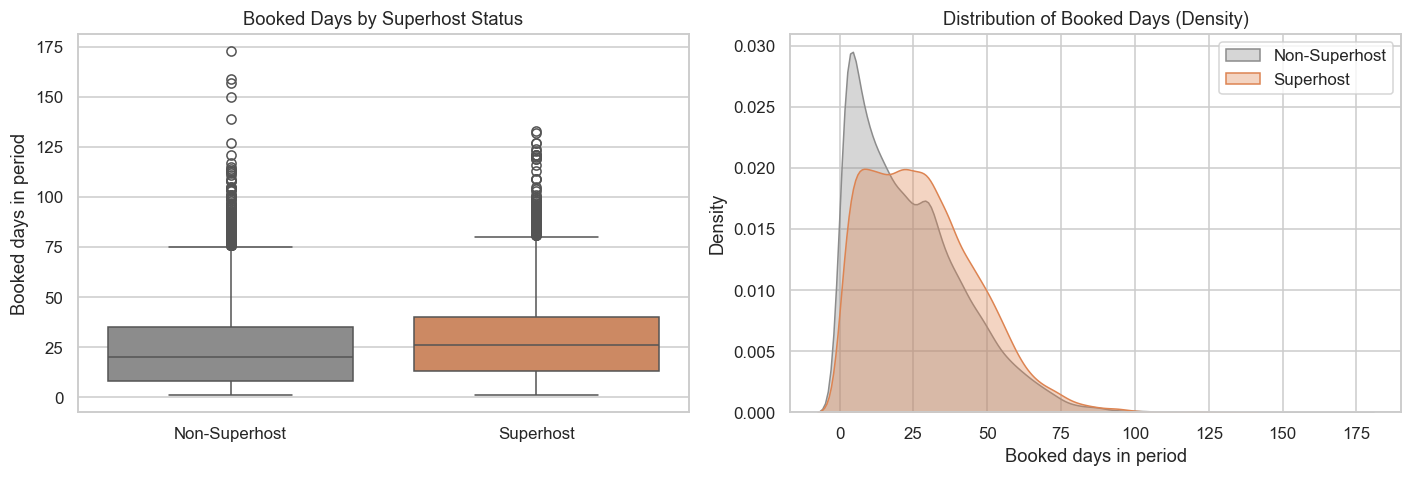

In [4]:
# Keep only rows that actually have booking data. subset= means 'judge missingness
# on this column only', not on the whole row.
bd = df.dropna(subset=['booked_days'])
print('Rows used: {} of {} ({} dropped for null booked_days)'.format(
    len(bd), len(df), df['booked_days'].isna().sum()))
print()

# A groupby object: the same calculation gets applied once per group.
grp = bd.groupby('Superhost status')['booked_days']
tbl = pd.DataFrame({
    'Count':  grp.count(),
    'Mean':   grp.mean(),
    'Median': grp.median(),
    'Std dev': grp.std(),
    'Q1':     grp.quantile(0.25),
    'Q3':     grp.quantile(0.75),
    'Max':    grp.max(),
})
tbl['IQR'] = tbl['Q3'] - tbl['Q1']
print('booked_days by Superhost status')
print(tbl.round(2).to_string())
print()

# Split into the two groups so we can difference them directly.
sh = bd.loc[bd['Superhost'] == 1, 'booked_days']
non = bd.loc[bd['Superhost'] == 0, 'booked_days']
print('Difference in means  (Superhost - Non): {:+.2f} days'.format(sh.mean() - non.mean()))
print('Difference in medians (Superhost - Non): {:+.2f} days'.format(sh.median() - non.median()))
print('Superhost median is {:.1f}x the non-Superhost median'.format(sh.median() / non.median()))
print()

# Unbooked periods are excluded above; that itself differs by group, so report it.
print('Share of property-periods with NO bookings at all:')
# Share of each group's rows that are missing - i.e. periods with zero bookings.
# This runs on the FULL df, not bd, because bd has already dropped those rows.
print((df.groupby('Superhost status')['booked_days'].apply(lambda s: s.isna().mean())
         .mul(100).round(1).astype(str) + '%').to_string())

# Box plot of booked days by group to compare medians, spread and outliers,
# plus density curves to show whether the two distributions differ in shape.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=bd, x='Superhost status', y='booked_days',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
axes[0].set_title('Booked Days by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Booked days in period')

for lab, colr in [('Non-Superhost', '#8C8C8C'), ('Superhost', '#DD8452')]:
    sns.kdeplot(bd.loc[bd['Superhost status'] == lab, 'booked_days'],
                label=lab, fill=True, alpha=0.35, color=colr, ax=axes[1])
axes[1].set_title('Distribution of Booked Days (Density)')
axes[1].set_xlabel('Booked days in period'); axes[1].set_ylabel('Density')
axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 3

Why box plots? The question asks us to choose, and the choice matters here: a bar chart of
two means would report a 4.5-day gap and hide the fact that both distributions are wide and
heavily overlapping. Box plots show median, IQR and outliers for both groups at once; the
density curves beside them show whether the *shapes* differ or only the centres.

| | n | Mean | Median | Q1 | Q3 | IQR |
|---|---|---|---|---|---|---|
| Non-Superhost | 18,987 | 23.67 | 20.0 | 8.0 | 35.0 | 27.0 |
| Superhost | 12,863 | 28.12 | 26.0 | 13.0 | 40.0 | 27.0 |

Superhosts book +4.46 days more on the mean and +6.0 days more on the median — the median
gap is the larger of the two, so this is not a handful of outliers dragging an average. What the box plots add is that the IQR is identical at 27 days for both groups: the Superhost
distribution is not tighter or more consistent, it is the same shape shifted upward by about a week of bookings per period. Superhost listings are not a different kind of business, just a better-booked version of the same one.

The largest difference is one the box plots cannot show, because it lives in the rows we had
to drop. Among non-Superhosts, 42.1% of property-periods had no bookings at all; among
Superhosts, only 19.2%. So the real booking-pattern gap is not mainly that a booked
Superhost books more nights — it is that a Superhost listing is less than half as likely to
sit empty for an entire period. Any comparison restricted to booked rows understates the
advantage by a wide margin.

---
# Question 4 — Seasonal patterns in booking days for Superhosts

> *Are there any seasonal patterns in the booking days for Superhosts? Select the best approach
> to visualize the trend in booked_days over different periods and discuss the patterns.*

Chart choice and why. A line chart of mean `booked_days` by calendar month, restricted to
Superhosts. "Seasonal" means calendar months, so this is the first question that uses
`Scraped Date` rather than the period number. We add the non-Superhost line even though the
question doesn't ask for it: if both lines share the same shape, the pattern is the Dallas
market, not something about Superhosts.

Watch for: We check how many years and which months are actually present before averaging
months across years — the scrape is quarterly, so not every calendar month is covered.

Date range: 2016-08-01 to 2020-06-22
Distinct years  : [2016, 2017, 2018, 2019, 2020]
Distinct months present: [2, 3, 5, 6, 8, 9, 11, 12]
NOTE: scrapes are quarterly, so only 8 of 12 calendar months appear. Months with no
      scrape are absent from the chart, not zero.

Mean booked_days by calendar month (all months present in the data)
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                       24.77      27.86
Mar                       21.27      17.42
May                       22.74      30.12
Jun                       13.35      21.25
Aug                       26.72      29.64
Sep                       17.94      19.00
Nov                       20.85      25.11
Dec                       17.86      21.62

Rows behind each month
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                        4561       3329
Mar                          33         12
May                        4859  

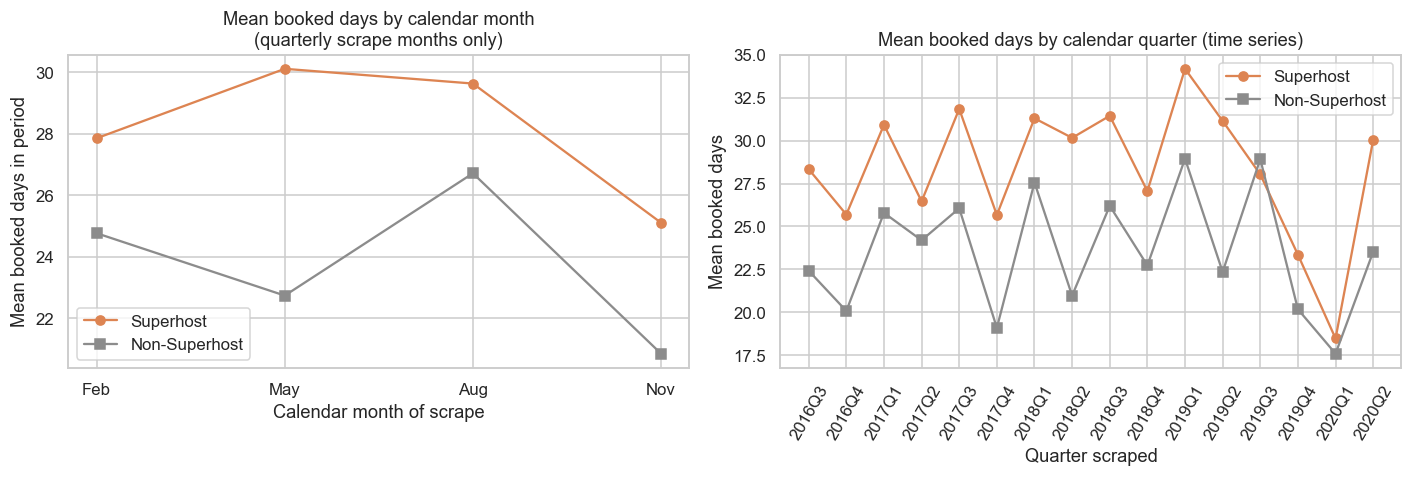


Mean booked_days by quarter (time series above)
Superhost status  Non-Superhost  Superhost
Scraped Date                              
2016Q3                    22.42      28.34
2016Q4                    20.07      25.69
2017Q1                    25.79      30.93
2017Q2                    24.19      26.46
2017Q3                    26.06      31.85
2017Q4                    19.09      25.67
2018Q1                    27.56      31.31
2018Q2                    20.97      30.17
2018Q3                    26.20      31.45
2018Q4                    22.73      27.06
2019Q1                    28.95      34.19
2019Q2                    22.35      31.15
2019Q3                    28.93      28.03
2019Q4                    20.17      23.36
2020Q1                    17.58      18.47
2020Q2                    23.52      30.05


In [5]:
# Q4: seasonality. This needs real calendar dates, so parse the date column first.
df['Scraped Date'] = pd.to_datetime(df['Scraped Date'])
print('Date range: {} to {}'.format(df['Scraped Date'].min().date(), df['Scraped Date'].max().date()))
print('Distinct years  :', sorted(df['Scraped Date'].dt.year.unique()))
print('Distinct months present:', sorted(df['Scraped Date'].dt.month.unique()))
print('NOTE: scrapes are quarterly, so only {} of 12 calendar months appear. Months with no'
      .format(df['Scraped Date'].dt.month.nunique()))
print('      scrape are absent from the chart, not zero.')
print()

# Pull calendar month and year out of the date for grouping.
df['Month'] = df['Scraped Date'].dt.month
df['Year'] = df['Scraped Date'].dt.year
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

bd = df.dropna(subset=['booked_days'])
# Mean, median and row count of booked days for each month/group combination.
monthly = (bd.groupby(['Month', 'Superhost status'])['booked_days']
             .agg(['mean', 'median', 'count']).round(2).reset_index())
# pivot reshapes long -> wide: one row per month, one column per group.
piv_mean = monthly.pivot(index='Month', columns='Superhost status', values='mean')
piv_n = monthly.pivot(index='Month', columns='Superhost status', values='count')

print('Mean booked_days by calendar month (all months present in the data)')
print(piv_mean.rename(index=month_names).round(2).to_string())
print()
print('Rows behind each month')
print(piv_n.rename(index=month_names).astype(int).to_string())
print()

# Four months hold only a handful of straggler scrapes. Averaging 12 rows next to 3,300
# would invent a seasonal swing that is really sampling noise, so we read the pattern off
# the well-sampled months only and say which those are.
# .all(axis=1) demands the threshold is met in BOTH columns, so a month only counts
# as well-sampled if both groups have enough rows.
well = piv_n[(piv_n >= 500).all(axis=1)].index.tolist()
thin = [m for m in piv_n.index if m not in well]
print('Well-sampled months (>=500 rows in BOTH groups):', [month_names[m] for m in well])
print('Thin months excluded from the chart          :',
      ['{} (n={})'.format(month_names[m], int(piv_n.loc[m].sum())) for m in thin])
print()

# Peak and trough months, read off the well-sampled months only.
pm = piv_mean.loc[well]
sh_m = pm['Superhost']
print('Superhost peak month : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmax()], sh_m.max()))
print('Superhost low month  : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmin()], sh_m.min()))
print('Peak-to-trough swing : {:.1f} days ({:.0%} above the low month)'.format(
    sh_m.max() - sh_m.min(), (sh_m.max() - sh_m.min()) / sh_m.min()))
non_m = pm['Non-Superhost']
print('Non-Superhost peak   : {}   low: {}   swing: {:.1f} days'.format(
    month_names[non_m.idxmax()], month_names[non_m.idxmin()], non_m.max() - non_m.min()))
# Vertical gap between the two lines on the chart: how many more days a Superhost
# listing books than a non-Superhost one, in each month.
print()
lead = (pm['Superhost'] - pm['Non-Superhost']).rename(index=month_names).round(2)
lead.index.name = None          # drop the stray 'Month' header pandas prints
print('Superhost lead in mean booked days (Superhost - Non-Superhost), by month:')
print(lead.to_string())

# Left: line chart of booked days by calendar month to show the seasonal cycle.
# Right: the same measure by quarter over time, to separate cycle from trend.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[0].plot(range(len(well)), pm[lab], marker=mk, color=colr, label=lab)
axes[0].set_xticks(range(len(well)))
axes[0].set_xticklabels([month_names[m] for m in well])
axes[0].set_title('Mean booked days by calendar month\n(quarterly scrape months only)')
axes[0].set_xlabel('Calendar month of scrape')
axes[0].set_ylabel('Mean booked days in period')
axes[0].legend(title='')

# Second view: the actual time series, so a repeating cycle can be told apart from a trend.
# .dt.to_period('Q') buckets each date into its calendar quarter (e.g. 2019Q2).
# .unstack() then moves the Superhost labels up into columns.
ts = (bd.groupby([bd['Scraped Date'].dt.to_period('Q'), 'Superhost status'])['booked_days']
        .mean().unstack())
ts.index = ts.index.astype(str)
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[1].plot(ts.index, ts[lab], marker=mk, color=colr, label=lab)
axes[1].set_title('Mean booked days by calendar quarter (time series)')
axes[1].set_xlabel('Quarter scraped'); axes[1].set_ylabel('Mean booked days')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend(title='')
plt.tight_layout()
plt.show()

print()
print('Mean booked_days by quarter (time series above)')
print(ts.round(2).to_string())

### Findings — Question 4

**A sampling caveat first, because it changes the answer.** The data is scraped **quarterly**,
so only 8 of 12 calendar months appear at all, and 4 of those (Mar, Jun, Sep, Dec) hold just a
few dozen straggler rows against 3,000+ in the real scrape months. Reading a "March trough" off
12 Superhost rows would be inventing a season out of sampling noise. We therefore read the
pattern off the four well-sampled months — **February, May, August, November** — and exclude the
rest from the chart.

Mean booked days for Superhosts: **Feb 27.9 · May 30.1 · Aug 29.6 · Nov 25.1**.

**The pattern.** There is a clear and modest season. Superhost bookings peak in **May (30.1
days)**, hold nearly as high through **August (29.6)**, and fall to a low in **November (25.1)** —
a **5.0-day swing, about 20%** between the best and worst month. Spring and summer are the
Dallas booking season; late autumn is the trough.

**The season is the market, not the badge.** Non-Superhosts follow the same shape (peak Aug
26.7, trough Nov 20.9), which tells us this is Dallas demand rather than anything Superhosts do.
What *is* specific to Superhosts is that their line sits above the non-Superhost line in **every
month**, by 2.9 to 7.4 days, and the gap is widest in the peak month of May. Superhosts capture
disproportionately more of the seasonal upside.

**The quarterly time series adds a caution about reading months across years.** It shows the
seasonal cycle repeating on top of a mild upward drift from 2016 to 2019, then a visible dip in
**2020 Q1 (Superhost mean 18.5 booked days, the lowest point in the series)** as COVID hit. Since
the monthly averages pool five years together, that shock is silently mixed into the Feb figure.

---
# Question 5 — Superhost status and number of reviews

> *How does Superhost status impact the number of reviews a property receives? Choose an
> appropriate method to compare the numReviews_pastYear for Superhosts and non-Superhosts.*

**Method choice and why.** Group summary statistics plus box plots, backed by two significance
tests. Review counts are right-skewed and the two groups differ in size and variance, so we use
**Welch's t-test** (does not assume equal variances) for the means and **Mann-Whitney U** as a
non-parametric check that does not assume normality. If both agree, the gap is not sampling
noise.

**Important caveat for the written answer.** This is correlational, and the direction is
ambiguous: Superhost status is *awarded partly on the basis of review activity*, so we cannot
claim the badge causes reviews. It is at least as likely that reviews cause the badge.

Rows used: 37492 of 48711 (11219 dropped for null numReviews_pastYear)



numReviews_pastYear by Superhost status
                  Count    Mean  Median  Std dev    Q1     Q3     Max
Superhost status                                                     
Non-Superhost     22546  240.49    27.0   601.66   5.0  184.0  3305.0
Superhost         14946  138.78    46.0   288.59  20.0  131.0  3133.0

Difference in means  : -101.71 reviews  (Superhost 138.8 vs 240.5)
Difference in medians: +19.0 reviews  (Superhost 46 vs 27)
Superhost mean is 0.58x the non-Superhost mean

Welch's t-test (unequal variances)
  t-statistic = -21.870
  p-value     = 2.614e-105  (< 0.001)
Mann-Whitney U (non-parametric check)
  U-statistic = 199,394,438
  p-value     = 2.198e-199  (< 0.001)

Cohen's d (effect size) = -0.203
  For scale: 0.2 small, 0.5 medium, 0.8 large.


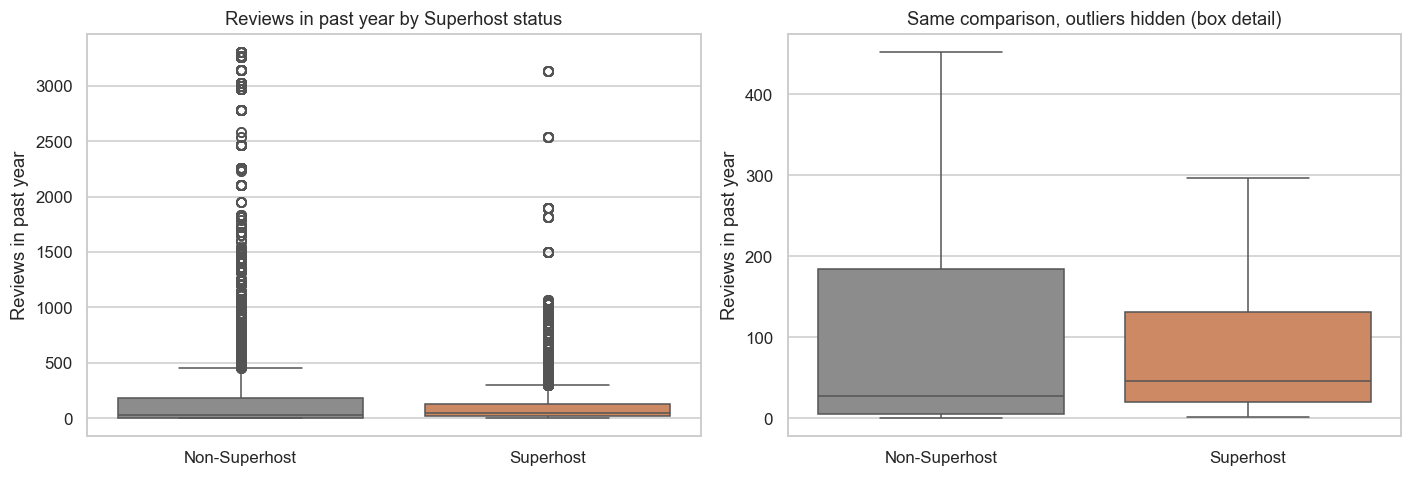

In [6]:
# Q5: do Superhosts receive more reviews than non-Superhosts?
rv = df.dropna(subset=['numReviews_pastYear'])
print('Rows used: {} of {} ({} dropped for null numReviews_pastYear)'.format(
    len(rv), len(df), df['numReviews_pastYear'].isna().sum()))
print()

# Summary table of review counts for each group.
grp = rv.groupby('Superhost status')['numReviews_pastYear']
tbl = pd.DataFrame({'Count': grp.count(), 'Mean': grp.mean(), 'Median': grp.median(),
                    'Std dev': grp.std(), 'Q1': grp.quantile(0.25), 'Q3': grp.quantile(0.75),
                    'Max': grp.max()})
print('numReviews_pastYear by Superhost status')
print(tbl.round(2).to_string())
print()

# Split the two groups so they can be compared and tested.
sh = rv.loc[rv['Superhost'] == 1, 'numReviews_pastYear']
non = rv.loc[rv['Superhost'] == 0, 'numReviews_pastYear']
print('Difference in means  : {:+.2f} reviews  (Superhost {:.1f} vs {:.1f})'.format(
    sh.mean() - non.mean(), sh.mean(), non.mean()))
print('Difference in medians: {:+.1f} reviews  (Superhost {:.0f} vs {:.0f})'.format(
    sh.median() - non.median(), sh.median(), non.median()))
print('Superhost mean is {:.2f}x the non-Superhost mean'.format(sh.mean() / non.mean()))
print()

# equal_var=False makes this Welch's t-test, which does not assume the two groups
# have the same variance or size - both are true here.
t, p = stats.ttest_ind(sh, non, equal_var=False)
print("Welch's t-test (unequal variances)")
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Compares ranks rather than means, so a few huge values cannot distort it.
u, pu = stats.mannwhitneyu(sh, non, alternative='two-sided')
print('Mann-Whitney U (non-parametric check)')
print('  U-statistic = {:,.0f}'.format(u))
print('  p-value     = {:.3e}{}'.format(pu, '  (< 0.001)' if pu < 0.001 else ''))
# Effect size: a significant p-value on 37k rows says little on its own.
# Cohen's d = gap between means measured in standard deviations. On 37k rows almost
# any gap is 'significant', so this says whether it is actually BIG.
pooled = np.sqrt(((len(sh)-1)*sh.var() + (len(non)-1)*non.var()) / (len(sh)+len(non)-2))
print("\nCohen's d (effect size) = {:.3f}".format((sh.mean() - non.mean()) / pooled))
print('  For scale: 0.2 small, 0.5 medium, 0.8 large.')

# Box plots of reviews by group. The second hides outliers so the boxes themselves
# are readable - the tail is so long it flattens the first chart.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
axes[0].set_title('Reviews in past year by Superhost status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Reviews in past year')

sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=axes[1])
axes[1].set_title('Same comparison, outliers hidden (box detail)')
axes[1].set_xlabel(''); axes[1].set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Q5 follow-up — the mean and the median disagree, so we check why

The table above shows something odd: Superhosts have a **higher median** review count but a
**lower mean**. When those two point in opposite directions, a skewed tail is driving the mean,
and we should find out what is in that tail before writing an answer.

Our hypothesis: `numReviews_pastYear` scales with how many listings a host operates, so large
commercial operators sit in the tail — and those operators are concentrated among
non-Superhosts. We test it by counting listings per host and re-running the comparison on
**single-listing hosts only**, which removes the confound.

Mean reviews by size of host portfolio (distinct listings operated)
           count   mean  median
n_props                        
1 listing  10569   19.8     9.0
2           4858   35.2    18.0
3-5         5635   55.0    28.0
6-20        6438  260.2   110.0
21+         9992  513.5   188.0

-> Review counts rise steeply with portfolio size, so this column reflects the HOST,
   not just the property.

Portfolio size by Superhost status
                   mean  median
Superhost status               
Non-Superhost     72.79     5.0
Superhost         39.54     3.0

-> Non-Superhosts operate far larger portfolios on average, which is what pulls their
   MEAN review count above the Superhost mean.

Like-for-like comparison: single-listing hosts only (n = 10569)
                  count   mean  median    std
Superhost status                             
Non-Superhost      6547  12.52     4.0  54.04
Superhost          4022  31.65    22.5  30.26

Superhost mean is 2.53x the non-Superhost mean  

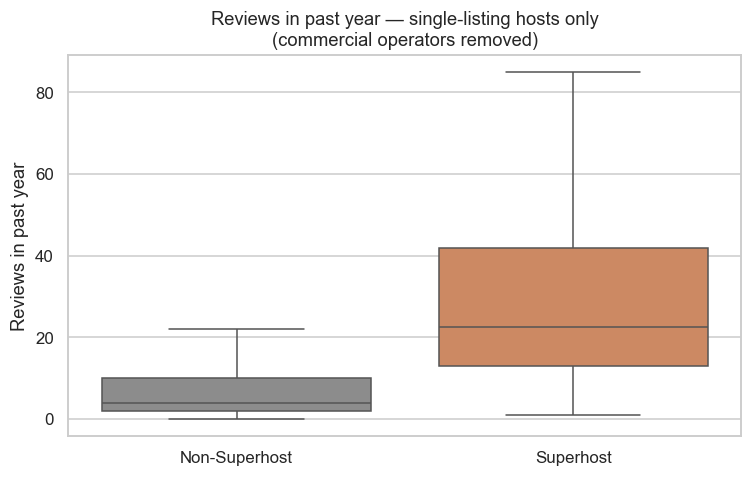

In [7]:
# How many distinct properties does each host operate?
# nunique() counts DISTINCT properties per host, so a host appearing in many periods
# is still counted once per property.
props_per_host = rv.groupby('Airbnb Host ID')['Airbnb Property ID'].nunique().rename('n_props')
# join(..., on=) attaches that host-level count back onto every row of that host.
rv2 = rv.join(props_per_host, on='Airbnb Host ID')

# Does review count track how many listings a host runs?
print('Mean reviews by size of host portfolio (distinct listings operated)')
# pd.cut sorts a numeric column into labelled bands. Edges are (0,1], (1,2] ... so
# '1 listing' means exactly one.
bands = pd.cut(rv2['n_props'], [0, 1, 2, 5, 20, 10000],
               labels=['1 listing', '2', '3-5', '6-20', '21+'])
print(rv2.groupby(bands, observed=True)['numReviews_pastYear']
         .agg(['count', 'mean', 'median']).round(1).to_string())
print()
print('-> Review counts rise steeply with portfolio size, so this column reflects the HOST,')
print('   not just the property.')
print()
# Compare typical portfolio size between the two groups.
print('Portfolio size by Superhost status')
print(rv2.groupby('Superhost status')['n_props'].agg(['mean', 'median']).round(2).to_string())
print()
print('-> Non-Superhosts operate far larger portfolios on average, which is what pulls their')
print('   MEAN review count above the Superhost mean.')
print()

# Re-run the comparison with the confound removed.
# Hosts with exactly one listing: removes commercial operators, which is the
# confound that made the mean and median disagree above.
single = rv2[rv2['n_props'] == 1]
print('=' * 62)
print('Like-for-like comparison: single-listing hosts only (n = {})'.format(len(single)))
print('=' * 62)
print(single.groupby('Superhost status')['numReviews_pastYear']
            .agg(['count', 'mean', 'median', 'std']).round(2).to_string())
print()
a = single.loc[single['Superhost'] == 1, 'numReviews_pastYear']
b = single.loc[single['Superhost'] == 0, 'numReviews_pastYear']
print('Superhost mean is {:.2f}x the non-Superhost mean   ({:.1f} vs {:.1f})'.format(
    a.mean() / b.mean(), a.mean(), b.mean()))
print('Superhost median is {:.2f}x the non-Superhost median ({:.1f} vs {:.1f})'.format(
    a.median() / b.median(), a.median(), b.median()))
print("Welch's t-test p-value : {:.3e}".format(stats.ttest_ind(a, b, equal_var=False)[1]))
print('Mann-Whitney U p-value : {:.3e}'.format(stats.mannwhitneyu(a, b, alternative='two-sided')[1]))

# Box plot of reviews for single-listing hosts only - the like-for-like comparison,
# with commercial operators removed.
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=single, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=ax)
ax.set_title('Reviews in past year — single-listing hosts only\n(commercial operators removed)')
ax.set_xlabel(''); ax.set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Findings — Question 5

**The headline comparison contradicts itself, and that is the interesting part.** Across all
37,492 rows with review data, Superhosts have a **higher median** (46 vs 27 reviews) but a
**lower mean** (138.8 vs 240.5). Both tests are significant (Welch p ≈ 3e-105, Mann-Whitney
p ≈ 2e-199), but they are significant in *opposite directions*, so significance is not the issue
— on 37,000 rows almost anything reaches significance, which is why we also report Cohen's d
(**-0.20**, small). A p-value cannot tell us which of two contradictory answers is right.

**What is in the tail.** `numReviews_pastYear` rises steeply with the size of the host's
portfolio — from a mean of **19.8 reviews for single-listing hosts to 513.5 for hosts with 21+
listings**. The column reflects the *host*, not the individual property. And non-Superhosts
operate much larger portfolios on average (**72.8 listings vs 39.5**). So the non-Superhost mean
is inflated by large commercial operators, who accumulate enormous review counts and rarely hold
Superhost status.

**The like-for-like answer.** Restricting to hosts with exactly one listing (n = 10,569) removes
the confound, and the contradiction disappears — both statistics now point the same way:

| Single-listing hosts | n | Mean | Median |
|---|---|---|---|
| Non-Superhost | 6,547 | 12.5 | 4.0 |
| Superhost | 4,022 | 31.7 | 22.5 |

Superhosts receive **2.5x the mean and 5.6x the median** number of reviews (both p < 0.001).
That is the finding: **Superhost status is associated with substantially more reviews**, and the
raw comparison hid it entirely behind a composition effect.

**Causation caveat.** This is correlational, and the direction is genuinely ambiguous — Airbnb
awards Superhost status *partly on the basis of review activity*, so it is at least as plausible
that reviews cause the badge as the reverse. We cannot separate the two with this data.

---
# Question 6 — Histogram of revenue by Superhost status

> *Use a histogram to visualize the distribution of revenue for listings. How does the
> distribution differ between properties with Superhost status and those without?*

**Approach.** The question names the chart, so there is no choice to justify — but revenue is
heavily right-skewed, and a plain histogram is one tall bar near zero and a flat invisible tail.
We show **two versions on shared bins**: the raw scale, and a **log-scaled x-axis** where the
shape of both distributions is actually readable. We read the answer off the log version and say
so.

**Decision stated explicitly:** property-periods with no bookings (null revenue) are *excluded*
from the histograms, because a log axis cannot show zero. Their counts are printed below so the
exclusion is visible.

Rows used: 31850 of 48711 (16861 excluded — no bookings in the period)

revenue by Superhost status
                           Non-Superhost  Superhost
Count                           18987.00   12863.00
Mean                             2938.92    3422.28
Median                           1868.00    2229.00
Std dev                          3862.47    4748.83
Skewness                            4.83       7.24
Max                             77500.00  134209.00
Rows with revenue == 0              0.00       0.00
Unbooked periods excluded       13804.00    3057.00

Both groups are strongly right-skewed (skew >> 0), so the median describes a typical
property far better than the mean does.

Median revenue: Superhost $2,229 vs Non-Superhost $1,868  (+19%)
Mean revenue  : Superhost $3,422 vs Non-Superhost $2,939  (+16%)


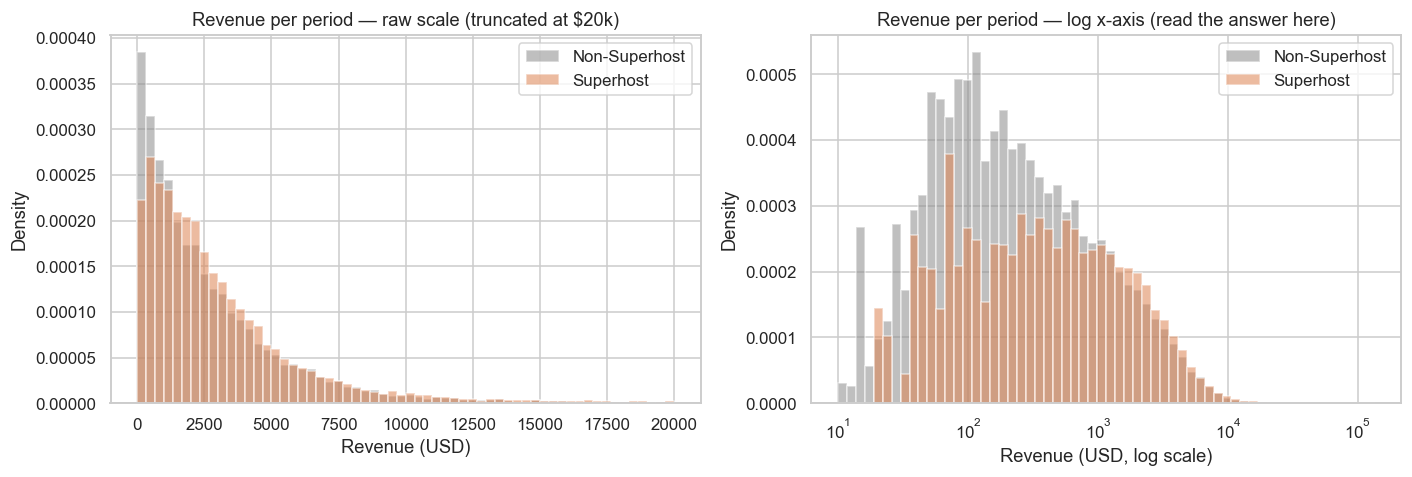

In [8]:
# Q6: shape of the revenue distribution, split by Superhost status.
rev = df.dropna(subset=['revenue'])
print('Rows used: {} of {} ({} excluded — no bookings in the period)'.format(
    len(rev), len(df), df['revenue'].isna().sum()))
print()

# Per-group revenue statistics, including skewness to quantify the right tail.
stats_tbl = pd.DataFrame({
    lab: {
        'Count':            g['revenue'].count(),
        'Mean':             g['revenue'].mean(),
        'Median':           g['revenue'].median(),
        'Std dev':          g['revenue'].std(),
        'Skewness':         g['revenue'].skew(),
        'Max':              g['revenue'].max(),
        'Rows with revenue == 0': int((g['revenue'] == 0).sum()),
        'Unbooked periods excluded': int(df[(df['Superhost status'] == lab)]['revenue'].isna().sum()),
    } for lab, g in rev.groupby('Superhost status')
})
print('revenue by Superhost status')
print(stats_tbl.round(2).to_string())
print()
print('Both groups are strongly right-skewed (skew >> 0), so the median describes a typical')
print('property far better than the mean does.')
print()
# Headline medians and means for the write-up.
sh = rev.loc[rev['Superhost'] == 1, 'revenue']
non = rev.loc[rev['Superhost'] == 0, 'revenue']
print('Median revenue: Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.median(), non.median(), sh.median() / non.median() - 1))
print('Mean revenue  : Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.mean(), non.mean(), sh.mean() / non.mean() - 1))

# Both groups must share identical bins or the histograms cannot be compared.
# linspace = evenly spaced; logspace = evenly spaced ON a log axis, so the bars
# stay equal width once the x-axis is logged.
bins_raw = np.linspace(0, 20000, 61)
bins_log = np.logspace(np.log10(max(rev['revenue'].min(), 1)), np.log10(rev['revenue'].max()), 61)

# Two overlapping histograms of revenue by group: raw scale on the left, log x-axis
# on the right where the skew stops hiding the shape.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lab, colr in [('Non-Superhost', '#8C8C8C'), ('Superhost', '#DD8452')]:
    s = rev.loc[rev['Superhost status'] == lab, 'revenue']
    # density=True converts counts to proportions. Essential here: there are far more
    # non-Superhost rows, so raw counts would make that group look taller everywhere.
    # alpha makes the overlapping region visible.
    axes[0].hist(s, bins=bins_raw, alpha=0.55, label=lab, color=colr, density=True)
    axes[1].hist(s, bins=bins_log, alpha=0.55, label=lab, color=colr, density=True)
axes[0].set_title('Revenue per period — raw scale (truncated at $20k)')
axes[0].set_xlabel('Revenue (USD)'); axes[0].set_ylabel('Density'); axes[0].legend(title='')
axes[1].set_xscale('log')
axes[1].set_title('Revenue per period — log x-axis (read the answer here)')
axes[1].set_xlabel('Revenue (USD, log scale)'); axes[1].set_ylabel('Density'); axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 6

**Reading the log-scale chart, not the raw one.** Revenue is so heavily right-skewed (skewness
**7.24** for Superhosts, **4.83** for non-Superhosts) that the raw histogram is a spike near zero
and an invisible tail — you cannot compare shapes on it. On the log x-axis both distributions
resolve into a clear roughly log-normal bell, and that is the version we read the answer from.

| | n | Mean | Median | Skew | Max |
|---|---|---|---|---|---|
| Non-Superhost | 18,987 | $2,938.92 | $1,868 | 4.83 | $77,500 |
| Superhost | 12,863 | $3,422.28 | $2,229 | 7.24 | $134,209 |

**How the distributions differ.** They have the **same shape, shifted**: the Superhost curve sits
to the right of the non-Superhost curve across essentially its whole body, with a median **19%
higher ($2,229 vs $1,868)** and a mean **16% higher**. The shift is bigger at the median than at
the mean, meaning the Superhost advantage is a broad-based shift of ordinary listings rather
than a few stars. Superhosts are also *more* skewed (7.24 vs 4.83) and hold the single largest
observation ($134,209), so the top of the market is Superhost territory — but that tail is not
what moves the median.

**Two things the histogram cannot show.** First, no row records revenue of exactly $0 — the
minimum is $10 — so the "zero bar" people expect is absent by construction. Second, and more
important, we excluded **16,861 property-periods with no bookings** (a log axis cannot plot
zero), and they are not evenly split: **13,804 non-Superhost vs 3,057 Superhost**. Both
histograms are therefore conditioned on having earned anything at all, which flatters
non-Superhosts. Including the idle periods as zero would widen the Superhost advantage
considerably.

---
# Question 7 — Revenue before vs after gaining Superhost status

> *Create a bar chart comparing the average revenue for properties before and after gaining
> Superhost status. Does the revenue increase for properties that become Superhosts?*

**How this is done correctly.** This is the question the panel structure exists for. We filter to
rows where `superhost_change_gain_superhost == 1` — exactly the property-periods in which the
badge was gained. Within those rows, `prev_revenue` is the **before** value and `revenue` is the
**after** value **for the same property**.

Comparing all Superhost revenue against all non-Superhost revenue would answer a different and
much weaker question, because it compares *different properties*. Here each property is its own
control.

We therefore also run a **paired** t-test and report the mean of the per-property change, not
just the difference between two group means.

Property-periods where Superhost status was gained: 3428
Distinct properties in that set                   : 3036

Rows with BOTH before and after revenue recorded  : 2106  (1322 dropped: 1003 null prev_revenue, 722 null revenue)
NOTE: a dropped row is usually a period with no bookings on one side, so this comparison
      describes properties that were booked both before and after gaining the badge.

Revenue before vs after gaining Superhost status
         Before Superhost (prev_revenue)  After Superhost (revenue)
Mean                             3362.58                    3154.07
Median                           2361.00                    2200.00
Std dev                          4052.74                    3915.15
Count                            2106.00                    2106.00

Per-property change in revenue (after - before)
  Mean change   : $-208.51
  Median change : $-152.50
  Properties whose revenue increased: 45.8%
  Properties whose revenue decreased: 53.8%
  Mean change a

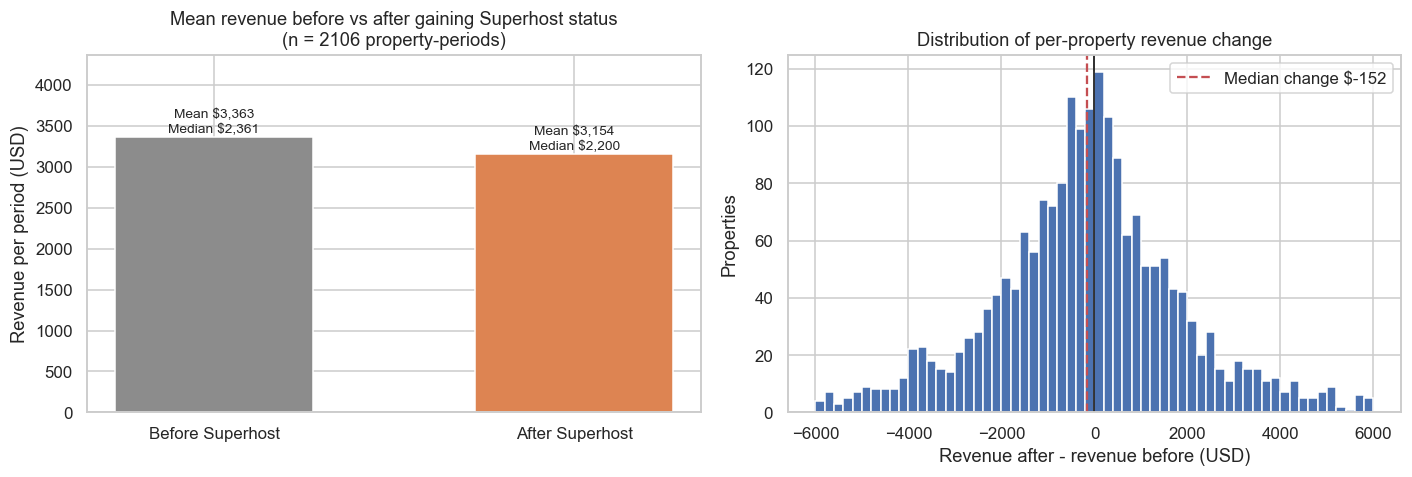

In [9]:
# The periods in which a property GAINED the badge. In these rows prev_revenue is
# the 'before' and revenue is the 'after' - same property, so it is its own control.
gain = df[df['superhost_change_gain_superhost'] == 1]
print('Property-periods where Superhost status was gained: {}'.format(len(gain)))
print('Distinct properties in that set                   : {}'.format(gain['Airbnb Property ID'].nunique()))
print()

# A paired test needs both halves present, so drop rows missing either side.
paired = gain.dropna(subset=['revenue', 'prev_revenue'])
print('Rows with BOTH before and after revenue recorded  : {}  ({} dropped: {} null prev_revenue,'
      ' {} null revenue)'.format(len(paired), len(gain) - len(paired),
                                 gain['prev_revenue'].isna().sum(), gain['revenue'].isna().sum()))
print('NOTE: a dropped row is usually a period with no bookings on one side, so this comparison')
print('      describes properties that were booked both before and after gaining the badge.')
print()

# Before/after summary table for the properties that gained the badge.
before, after = paired['prev_revenue'], paired['revenue']
comp = pd.DataFrame({
    'Before Superhost (prev_revenue)': {'Mean': before.mean(), 'Median': before.median(),
                                        'Std dev': before.std(), 'Count': before.count()},
    'After Superhost (revenue)':       {'Mean': after.mean(), 'Median': after.median(),
                                        'Std dev': after.std(), 'Count': after.count()},
})
print('Revenue before vs after gaining Superhost status')
print(comp.round(2).to_string())
print()

# Each property's own revenue change, which is what a paired comparison needs.
change = after - before
print('Per-property change in revenue (after - before)')
print('  Mean change   : ${:+,.2f}'.format(change.mean()))
print('  Median change : ${:+,.2f}'.format(change.median()))
print('  Properties whose revenue increased: {:.1%}'.format((change > 0).mean()))
print('  Properties whose revenue decreased: {:.1%}'.format((change < 0).mean()))
print('  Mean change as % of mean before   : {:+.1%}'.format(change.mean() / before.mean()))
print()

# ttest_REL (related), not ind: the two samples are the same properties measured
# twice, so the test looks at each property's own change.
t, p = stats.ttest_rel(after, before)
print('Paired t-test (same property measured twice)')
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Rank-based version of the paired test - a check that does not assume normality.
w, pw = stats.wilcoxon(after, before)
print('Wilcoxon signed-rank (non-parametric check)')
print('  statistic = {:,.0f}   p-value = {:.3e}'.format(w, pw))

# Left: bar chart of mean revenue before vs after gaining the badge.
# Right: histogram of per-property change, to show how wide the spread around it is.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ['Before Superhost', 'After Superhost']
means = [before.mean(), after.mean()]
medians = [before.median(), after.median()]
bars = axes[0].bar(labels, means, color=['#8C8C8C', '#DD8452'], width=0.55)
for bar, mn, mdn in zip(bars, means, medians):
    axes[0].text(bar.get_x() + bar.get_width() / 2, mn + 60,
                 'Mean ${:,.0f}\nMedian ${:,.0f}'.format(mn, mdn), ha='center', fontsize=9)
axes[0].set_title('Mean revenue before vs after gaining Superhost status\n(n = {} property-periods)'.format(len(paired)))
axes[0].set_ylabel('Revenue per period (USD)')
axes[0].set_ylim(0, max(means) * 1.30)

axes[1].hist(change, bins=60, range=(-6000, 6000), color='#4C72B0', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(change.median(), color='#C44E52', ls='--',
                label='Median change ${:+,.0f}'.format(change.median()))
axes[1].set_title('Distribution of per-property revenue change')
axes[1].set_xlabel('Revenue after - revenue before (USD)')
axes[1].set_ylabel('Properties'); axes[1].legend()
plt.tight_layout()
plt.show()

### Q7 follow-up — before/after alone cannot answer the question

The before/after comparison says revenue went **down** slightly after the badge was gained.
Taken at face value that would suggest becoming a Superhost hurts revenue, which is almost
certainly wrong. The problem is that "before" and "after" are different points in time, and
Question 4 showed bookings swing hard with the season. If badges tend to be awarded going into
a weaker quarter, the drop is the calendar, not the badge.

So we add a **control group**: properties that did *not* gain the badge, measured across the
same period transitions. If gainers and non-gainers move together, the change is market-wide.
The difference between the two changes (a difference-in-differences) is the part that can
plausibly be attributed to the badge.

Gainers: n = 2106    Control (did not gain): n = 22774

Mean revenue change (this period - previous period), by evaluation period
                      Gainers  Control  Difference  Gainer rows
superhost_period_all                                           
5.0                     132.0   -301.0       433.0           60
6.0                   -1518.0   -574.0      -944.0           86
7.0                     435.0    822.0      -387.0           73
8.0                    -550.0   -401.0      -148.0          118
9.0                     262.0    -10.0       272.0          129
10.0                  -1344.0  -1136.0      -208.0          110
11.0                    510.0   1221.0      -711.0          178
12.0                  -1328.0  -1053.0      -275.0          122
13.0                    218.0    320.0      -103.0           89
14.0                   -430.0   -722.0       292.0          151
15.0                    882.0   1012.0      -131.0          169
16.0                   -364.0   -932.0

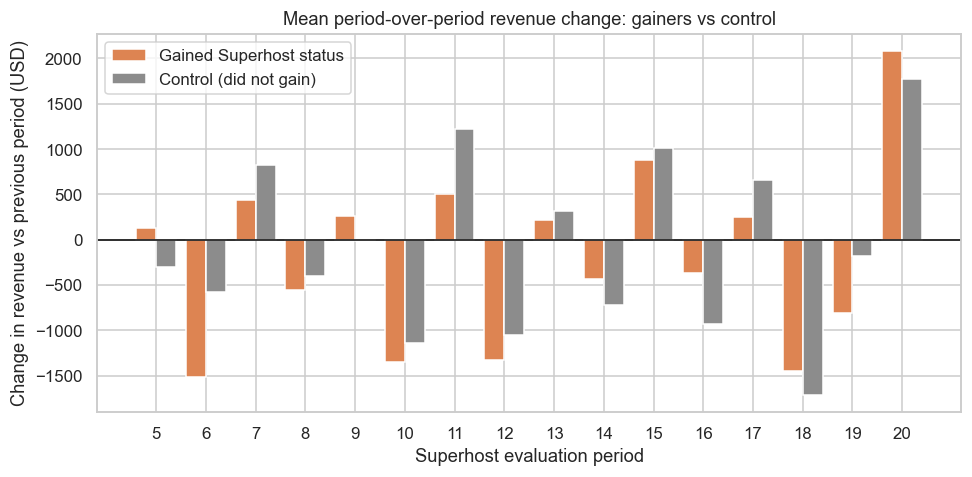

In [10]:
# Control group: properties that did NOT gain the badge, measured over the same
# period transitions. If both groups move together, the change is market-wide.
control = df[df['superhost_change_gain_superhost'] == 0].dropna(subset=['revenue', 'prev_revenue'])
print('Gainers: n = {}    Control (did not gain): n = {}'.format(len(paired), len(control)))
print()

# Group a Series by another column's values: average change per evaluation period.
gain_chg = (paired['revenue'] - paired['prev_revenue']).groupby(paired['superhost_period_all']).mean()
ctrl_chg = (control['revenue'] - control['prev_revenue']).groupby(control['superhost_period_all']).mean()
# Put both groups side by side, period by period.
comp = pd.DataFrame({'Gainers': gain_chg, 'Control': ctrl_chg})
comp['Difference'] = comp['Gainers'] - comp['Control']
comp['Gainer rows'] = paired['superhost_period_all'].value_counts().sort_index()
print('Mean revenue change (this period - previous period), by evaluation period')
print(comp.round(0).to_string())
print()
print('-> The change swings between roughly -$1,500 and +$2,100 depending on the period.')
print('   Seasonality dwarfs anything the badge could be doing, and the control group swings')
print('   with the gainers almost period for period.')
print()

# Weight the control by the periods in which gains actually happened, so we compare
# like with like rather than letting the control's period mix do the work.
# normalize=True turns counts into proportions - the share of badge-gains that
# happened in each period. These become the weights below.
w = paired['superhost_period_all'].value_counts(normalize=True).sort_index()
# Weighted average: re-weight the control group so its mix of periods matches the
# gainers'. Without this we would be comparing different seasons to each other.
ctrl_matched = (ctrl_chg.reindex(w.index) * w).sum()
gain_matched = (gain_chg.reindex(w.index) * w).sum()
print('Period-matched mean revenue change')
print('  Gainers                       : ${:+,.2f}'.format(gain_matched))
print('  Control, matched period mix   : ${:+,.2f}'.format(ctrl_matched))
print('  Difference-in-differences     : ${:+,.2f}'.format(gain_matched - ctrl_matched))
print()
print('Of the ${:+,.0f} raw before/after change, ${:+,.0f} is market-wide movement that the'.format(
    gain_matched, ctrl_matched))
print('control group experienced too. Only ${:+,.0f} is specific to gaining the badge.'.format(
    gain_matched - ctrl_matched))

# Grouped bar chart of period-over-period revenue change, gainers vs control,
# to show the two groups rising and falling together.
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['Gainers'], width=0.4, label='Gained Superhost status', color='#DD8452')
ax.bar(x + 0.2, comp['Control'], width=0.4, label='Control (did not gain)', color='#8C8C8C')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([int(p) for p in comp.index])
ax.set_title('Mean period-over-period revenue change: gainers vs control')
ax.set_xlabel('Superhost evaluation period')
ax.set_ylabel('Change in revenue vs previous period (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### Findings — Question 7

**Does revenue increase after gaining Superhost status? On this evidence, no — and the honest
answer is that the question as posed cannot be answered by a before/after bar chart.**

Of 3,428 property-periods where the badge was gained (3,036 distinct properties), **2,106** have
revenue recorded on both sides. For those:

| | Before (`prev_revenue`) | After (`revenue`) |
|---|---|---|
| Mean | $3,362.58 | $3,154.07 |
| Median | $2,361.00 | $2,200.00 |

Revenue **fell** by a mean of **-$208.51** and a median of **-$152.50**; only **45.8%** of
properties improved. The paired t-test (t = -2.77, p = 0.006) and Wilcoxon (p = 2e-05) both say
the decline is larger than chance.

**But the control group shows most of that decline is not about the badge.** Question 4
established that bookings swing seasonally, and "before" and "after" are different quarters. When
we measure the same period-over-period change for properties that did *not* gain the badge, they
move almost in lockstep — both groups swing between roughly **-$1,500 and +$2,100** depending on
which period transition you look at. Matching the control to the periods in which gains actually
occurred:

- Gainers: **-$208** per period
- Control, same period mix: **-$60**
- **Difference-in-differences: -$148**

So of the raw $208 decline, roughly **$60 is market-wide seasonal movement the control
experienced too**, and only about **$148 is specific to gaining the badge** — a **4% change on a
$3,363 base**, far smaller than the period-to-period noise surrounding it.

**Our conclusion.** There is **no evidence that gaining Superhost status raises revenue in the
period immediately after it is awarded**, and the small apparent decline is mostly seasonality.
The most likely explanation for the residual is **regression to the mean**: the badge is awarded
*following* an unusually strong stretch, so the "before" figure is measured at a local peak and
almost has to fall back. This does **not** contradict Question 6 — Superhosts really do earn more
than non-Superhosts. It says the badge is a *marker* of properties that were already performing
well, not a switch that lifts revenue the moment it is granted.

**Methodological note.** We report the mean of the per-property change, not the difference of two
group means, because the same property is measured twice. We also dropped 1,322 rows missing one
side, so this describes properties that were booked both before and after — properties that went
from idle to booked (or the reverse) are excluded, which is exactly where a badge effect might
otherwise show up.

---
# Question 8 — Revenue trend across evaluation periods

> *Use a line chart to illustrate the trend in revenue over multiple evaluation periods for
> Superhosts. How does Superhost status impact revenue over time?*

**Chart choice and why.** Mean revenue by `superhost_period_all`, with **both groups on one set of
axes**. A Superhost line on its own cannot distinguish "Superhosts are growing" from "the whole
Dallas market is growing" — the non-Superhost line is the control.

Given the skew found in Question 6 we plot the **median as well as the mean**, and print the row
count per period so thin periods can be flagged.

Mean / median revenue and row count by evaluation period
                                          mean  median  count
superhost_period_all Superhost status                        
5.0                  Non-Superhost     2448.19  1618.0    593
                     Superhost         3057.90  2546.0    239
6.0                  Non-Superhost     2269.10  1346.0    605
                     Superhost         2476.95  1779.0    301
7.0                  Non-Superhost     3149.52  1950.0    597
                     Superhost         3265.21  2400.0    313
8.0                  Non-Superhost     2780.24  1870.0    718
                     Superhost         3000.27  1949.5    426
9.0                  Non-Superhost     2814.00  1945.0    811
                     Superhost         3551.95  2571.0    573
10.0                 Non-Superhost     2194.88  1395.0    913
                     Superhost         2794.35  2070.0    723
11.0                 Non-Superhost     3731.82  2059.5    952
             

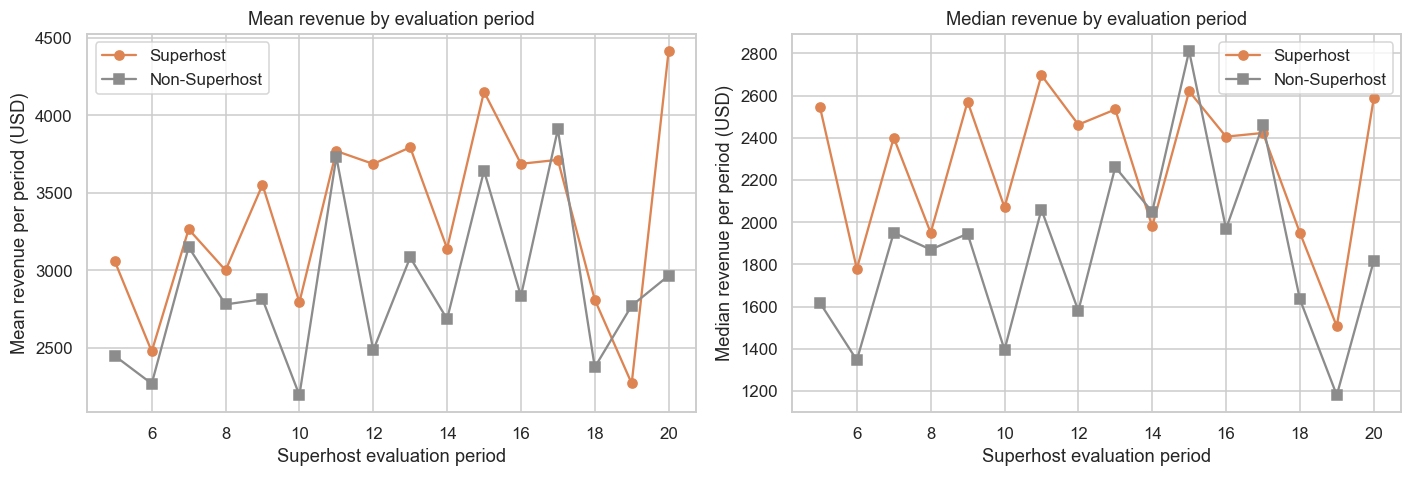

In [11]:
# Q8: revenue trend across evaluation periods for both groups.
rev = df.dropna(subset=['revenue'])
# Grouping by two columns gives a two-level index; .agg runs several statistics
# at once.
g = (rev.groupby(['superhost_period_all', 'Superhost status'])['revenue']
       .agg(['mean', 'median', 'count']).round(2))
print('Mean / median revenue and row count by evaluation period')
print(g.to_string())
print()

# unstack() lifts the inner index level (Superhost status) into columns, which is
# the shape matplotlib needs: one column per line on the chart.
piv_mean = g['mean'].unstack()
piv_med = g['median'].unstack()
piv_n = g['count'].unstack()

# .any(axis=1) flags a period if EITHER group is thin (vs .all which needs both).
# Flag any period with thin data before we read trends off the chart.
thin = piv_n[(piv_n < 100).any(axis=1)]
if len(thin):
    print('Periods with fewer than 100 rows in a group (treat with caution):')
    print(thin.astype(int).to_string())
else:
    print('No period has fewer than 100 rows in either group.')
print()

# Growth from the first period to the last, for each group.
first, last = piv_mean.index.min(), piv_mean.index.max()
for lab in ['Superhost', 'Non-Superhost']:
    print('{:<14} mean revenue: period {:.0f} = ${:,.0f}  ->  period {:.0f} = ${:,.0f}  ({:+.1%})'.format(
        lab, first, piv_mean.loc[first, lab], last, piv_mean.loc[last, lab],
        piv_mean.loc[last, lab] / piv_mean.loc[first, lab] - 1))
print()
# The Superhost revenue premium in each period.
gap = piv_mean['Superhost'] - piv_mean['Non-Superhost']
print('Superhost revenue premium (mean gap, USD per period)')
print(gap.round(0).to_string())
print('\nAverage premium across periods: ${:,.0f}'.format(gap.mean()))

# Line chart of revenue by period with one line per group, drawn twice:
# mean on the left, median on the right because revenue is so skewed.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, piv, name in [(axes[0], piv_mean, 'Mean'), (axes[1], piv_med, 'Median')]:
    for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
        ax.plot(piv.index, piv[lab], marker=mk, color=colr, label=lab)
    ax.set_title('{} revenue by evaluation period'.format(name))
    ax.set_xlabel('Superhost evaluation period')
    ax.set_ylabel('{} revenue per period (USD)'.format(name))
    ax.legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 8

**Why both groups on one chart.** A Superhost line alone cannot distinguish "Superhosts are
growing" from "Dallas is growing." The non-Superhost line is the control, and we plot the median
alongside the mean because Question 6 showed how skewed revenue is.

**Superhosts hold a persistent premium.** Mean revenue is higher for Superhosts in **14 of the 16
evaluation periods**, averaging **+$465 per property-period**. The exceptions are periods 17
(-$196) and 19 (-$502). The premium is not stable — it ranges from $38 (period 11) to $1,449
(period 20) — which fits the seasonal swings found in Question 4 rather than any steady trend.

**Over time, the gap widens.** From period 5 to period 20, mean Superhost revenue grew from
**$3,058 to $4,415 (+44.4%)**, while non-Superhosts grew from **$2,448 to $2,966 (+21.1%)** —
roughly double the growth rate. Both lines share the same saw-tooth shape, confirming that the
period-to-period movement is market seasonality affecting everyone.

**How to state the impact honestly.** Reading this as "Superhost status increases revenue over
time" would overstate it, and Question 7 is the reason: when we isolated properties at the moment
they gained the badge and compared them against a matched control, the effect was slightly
negative. The two results are consistent if Superhost status is largely a **marker of
consistently strong properties rather than a cause of revenue growth** — the badge tracks
listings that were already outperforming, and those listings continue to outperform and to widen
their lead. Selection is doing more work here than treatment.

Sample sizes support the comparison throughout: no period has fewer than 100 rows in either
group, though early periods are thinner (239 Superhost rows in period 5 vs 1,081 in period 20),
so the early points carry more sampling noise than the later ones.